# HIPE NER training on Colab

Standalone copy of the `hipe_ner` project, adapted to run on a Colab GPU
instead of Euler. This notebook is self-contained: run the cells top to
bottom and it recreates the whole project (source code, data, trained model)
inside your Google Drive, under `MyDrive/hipe_ner_colab/`.

**Nothing in your local `hipe_ner/` project is touched by this notebook.**

**Before you start:** in the Colab menu, go to **Runtime > Change runtime
type** and set **Hardware accelerator** to **GPU**. Which GPU you can pick
depends on your plan:
- **Free tier**: T4 only (no choice offered). Expect ~2-4h for the full
  8-epoch run (see step 7).
- **Colab Pro/Pro+**: under **GPU type** you can additionally pick
  **L4** or **A100** (A100 needs Pro+ or enough compute units). Either cuts
  the training time in step 7 well below the T4 estimate, and Pro's longer
  session/idle timeouts make you less likely to need the resume checkpoint
  described in step 7. T4 still works fine on Pro if you'd rather save your
  compute units -- it's a speed/cost tradeoff, not a correctness one.

Steps in this notebook:
1. Check the GPU is available
2. Mount Google Drive (so data/model/checkpoints survive between sessions)
3. Write out the project's source files
4. Install dependencies
5. Download the HIPE training data (~200MB, one-time)
6. Build the training dataset cache
7. Train
8. Evaluate + run on your own OCR-D text


The training completely finished (training done), and the trained model is safely saved in the Google Drive under checkpoints/stacked-hmbert-hipe/best.

When you come back to work on this another day, you will only need to run Step 2 (Mount Google Drive) and Step 4 (Install dependencies). After that, you can skip straight to Step 8 or Step 9 to evaluate or use your trained model on new text.

## 1. Check GPU

In [1]:
!nvidia-smi


Thu Sep 17 07:43:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive

This will pop up an authorization prompt -- click through it. Everything
this notebook creates (code, data, model checkpoints) lives under
`MyDrive/hipe_ner_colab/` in your Drive, so it survives if this Colab
session disconnects.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = "/content/drive/MyDrive/hipe_ner_colab"
for sub in ["src/hipe_ner", "scripts", "configs", "data", "checkpoints"]:
    os.makedirs(f"{PROJECT_ROOT}/{sub}", exist_ok=True)

# Cache hmBERT weights on Drive too, so you don't re-download ~440MB every session
os.environ["HF_HOME"] = f"{PROJECT_ROOT}/hf_cache"
%env HF_HOME=/content/drive/MyDrive/hipe_ner_colab/hf_cache
%cd /content/drive/MyDrive/hipe_ner_colab
print("project root:", PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
env: HF_HOME=/content/drive/MyDrive/hipe_ner_colab/hf_cache
/content/drive/MyDrive/hipe_ner_colab
project root: /content/drive/MyDrive/hipe_ner_colab


## 3. Write out the project source files

These cells recreate the exact same, already-tested `hipe_ner` package -- just written to Drive instead of copied from your Mac.

In [3]:
%%writefile pyproject.toml
[build-system]
requires = ["setuptools>=68"]
build-backend = "setuptools.build_meta"

[project]
name = "hipe-ner"
version = "0.1.0"
description = "Stacked hmBERT NER for HIPE-style historical NE recognition on OCR-D output"
requires-python = ">=3.10"
dependencies = [
    "torch",
    "transformers>=4.40",
    "datasets",
    "seqeval",
    "pyyaml",
    "segtok",
    "numpy",
]

[tool.setuptools.packages.find]
where = ["src"]


Writing pyproject.toml


In [4]:
%%writefile src/hipe_ner/__init__.py



Writing src/hipe_ner/__init__.py


In [5]:
%%writefile src/hipe_ner/label_scheme.py
"""Coarse label canonicalization across HIPE subsets.

The HIPE de/fr/en coarse-NE subsets do NOT share one label ontology:

  hipe2020  (de, fr):        pers, loc, org, prod, time
  letemps   (fr):             pers, loc, org
  newseye   (de, fr):         PER, LOC, ORG, HumanProd      <- different case!
  ajmc      (de, fr, en):     pers, loc, date, work, object, scope
  topres19th(en):             LOC, BUILDING, STREET
  sonar     (de):              pers, loc, org

Same-concept types that only differ by case/abbreviation (pers/PER, loc/LOC,
org/ORG) are folded together. Genuinely different concepts (hipe2020's
"prod" vs newseye's "HumanProd", ajmc's classics-commentary types) are kept
as distinct classes rather than guessed into one another. See README.md for
the reasoning and how to narrow this if you want a cleaner single-domain
label set instead of the full union.
"""
from __future__ import annotations

import json
from pathlib import Path

_ALIASES = {
    "pers": "PER",
    "per": "PER",
    "loc": "LOC",
    "org": "ORG",
    "prod": "PROD",
    "time": "TIME",
    "date": "DATE",
    "work": "WORK",
    "object": "OBJECT",
    "scope": "SCOPE",
    "humanprod": "HUMANPROD",
    "building": "BUILDING",
    "street": "STREET",
}


def canonicalize_tag(raw_tag: str) -> str:
    """'B-pers' -> 'B-PER', 'I-HumanProd' -> 'I-HUMANPROD', '_'/'O' -> 'O'."""
    if raw_tag in ("_", "", "O"):
        return "O"
    prefix, _, body = raw_tag.partition("-")
    if prefix not in ("B", "I") or not body:
        return "O"
    canon_body = _ALIASES.get(body.lower(), body.upper())
    return f"{prefix}-{canon_body}"


def build_label_list(tag_sequences) -> list[str]:
    """Collect the sorted, canonicalized label set from an iterable of raw
    per-token tag sequences (e.g. all training sentences)."""
    seen = {"O"}
    for tags in tag_sequences:
        for t in tags:
            seen.add(canonicalize_tag(t))
    # Deterministic order: O first, then B-/I- pairs grouped by type name.
    types = sorted({t[2:] for t in seen if t != "O"})
    labels = ["O"]
    for t in types:
        labels += [f"B-{t}", f"I-{t}"]
    return labels


def save_label_map(labels: list[str], path: str | Path) -> None:
    Path(path).write_text(json.dumps({"labels": labels}, indent=2, ensure_ascii=False), encoding="utf-8")


def load_label_map(path: str | Path) -> list[str]:
    return json.loads(Path(path).read_text(encoding="utf-8"))["labels"]


Writing src/hipe_ner/label_scheme.py


In [6]:
%%writefile src/hipe_ner/tsv_io.py
"""Reader for HIPE-2022 IOB TSV files.

Format (see https://github.com/hipe-eval/HIPE-2022-data):
  - one header line: TOKEN  NE-COARSE-LIT  NE-COARSE-METO  ...  MISC
  - comment lines starting with '#' (document metadata)
  - empty lines mark document boundaries
  - MISC carries pipe-separated flags; EndOfSentence marks sentence ends
    (there is no separate sentence-boundary column)
  - unannotated columns are '_'

We only need TOKEN, NE-COARSE-LIT and the EndOfSentence flag in MISC for a
coarse, flat BIO scheme. Everything else (fine type, components, nesting,
linking) is deliberately dropped here.
"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path


@dataclass
class Sentence:
    tokens: list[str]
    tags: list[str]  # raw NE-COARSE-LIT values, e.g. "B-pers", "O", "_"
    document_id: str | None = None


def read_hipe_tsv(path: str | Path) -> list[Sentence]:
    path = Path(path)
    lines = path.read_text(encoding="utf-8").splitlines()

    header = None
    col_idx: dict[str, int] = {}
    sentences: list[Sentence] = []
    cur_tokens: list[str] = []
    cur_tags: list[str] = []
    cur_doc_id: str | None = None

    def flush():
        nonlocal cur_tokens, cur_tags
        if cur_tokens:
            sentences.append(Sentence(cur_tokens, cur_tags, cur_doc_id))
        cur_tokens, cur_tags = [], []

    for raw_line in lines:
        line = raw_line.rstrip("\n")

        if header is None:
            if line.startswith("TOKEN"):
                header = line.split("\t")
                col_idx = {name: i for i, name in enumerate(header)}
            continue  # skip anything before the header (shouldn't happen)

        if line == "":
            # empty line = document boundary: always ends the current sentence too
            flush()
            continue

        if line.startswith("#"):
            if "document_id" in line:
                # "# hipe2022:document_id = NZZ-1798-01-20-a-p0001"
                cur_doc_id = line.split("=", 1)[-1].strip()
            continue

        fields = line.split("\t")
        token = fields[col_idx["TOKEN"]]
        tag = fields[col_idx["NE-COARSE-LIT"]]
        misc = fields[col_idx["MISC"]] if "MISC" in col_idx and len(fields) > col_idx["MISC"] else "_"

        cur_tokens.append(token)
        cur_tags.append(tag)

        if "EndOfSentence" in misc:
            flush()

    flush()
    return sentences


def iter_hipe_files(hipe_root: str | Path, dataset: str, lang: str, split: str) -> Path | None:
    """Locate the TSV for a given (dataset, lang, split), or None if absent.

    Not every dataset/language/split combination exists (e.g. hipe2020 has no
    English subset, some datasets ship no released test labels).
    """
    hipe_root = Path(hipe_root)
    pattern = f"HIPE-2022-*-{dataset}-{split}-{lang}.tsv"
    matches = sorted((hipe_root / dataset / lang).glob(pattern)) if (hipe_root / dataset / lang).is_dir() else []
    return matches[0] if matches else None


Writing src/hipe_ner/tsv_io.py


In [7]:
%%writefile src/hipe_ner/dataset.py
"""Tokenization and subword-label alignment for the cached HIPE JSONL files."""
from __future__ import annotations

from pathlib import Path

from datasets import Dataset


def load_jsonl_dataset(path: str | Path) -> Dataset:
    return Dataset.from_json(str(path))


def tokenize_and_align(examples, tokenizer, label2id: dict, max_length: int):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
    )
    all_labels = []
    for i, tags in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_id = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word_id:
                label_ids.append(label2id[tags[wid]])
            else:
                # subsequent subwords of the same word: don't score them
                label_ids.append(-100)
            prev_word_id = wid
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized


def build_tokenized_dataset(jsonl_path, tokenizer, label2id: dict, max_length: int) -> Dataset:
    ds = load_jsonl_dataset(jsonl_path)
    return ds.map(
        lambda ex: tokenize_and_align(ex, tokenizer, label2id, max_length),
        batched=True,
        remove_columns=ds.column_names,
        desc=f"tokenizing {Path(jsonl_path).name}",
    )


Writing src/hipe_ner/dataset.py


In [8]:
%%writefile src/hipe_ner/model.py
"""Stacked-BERT architecture: hmBERT encoder + a noise-adaptation Transformer
stack + a token-classification head.

    tokens -> hmBERT (dbmdz/bert-base-historic-multilingual-cased)
           -> [N extra Transformer encoder layers]   ("noise-adaptation stack")
           -> dropout -> linear -> per-token coarse NE logits

hmBERT was pretrained on clean(ish) digitized newspaper/book text, not on
the specific OCR-error distribution of any one downstream corpus. The extra
layers sit after the pretrained encoder and are fine-tuned only on the task,
so they're free to learn corrections for whatever spelling variation and
character-level noise show up in the *labeled* NER data (and, by extension,
generalize somewhat to similar noise in your own OCR-D output). The stack is
residual (input added back after the layers, then layer-normed) so early
training with a randomly initialized stack doesn't have to overwrite hmBERT's
good pretrained representations -- that's also why `freeze_base_epochs` exists
in training: give the stack a head start before hmBERT itself starts moving.
"""
from __future__ import annotations

import json
from dataclasses import asdict, dataclass
from pathlib import Path

import torch
from torch import nn
from transformers import AutoConfig, AutoModel
from transformers.modeling_outputs import TokenClassifierOutput


@dataclass
class StackedHistBertConfig:
    base_model: str = "dbmdz/bert-base-historic-multilingual-cased"
    num_labels: int = 2
    num_extra_layers: int = 2
    num_heads: int = 8
    ffn_size: int = 1024
    dropout: float = 0.1
    classifier_dropout: float = 0.1


class NoiseAdaptationStack(nn.Module):
    def __init__(self, hidden_size, num_layers, num_heads, ffn_size, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_size,
                nhead=num_heads,
                dim_feedforward=ffn_size,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(hidden_size)

    def forward(self, hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # nn.TransformerEncoderLayer's padding mask convention is the inverse
        # of HF's attention_mask: True means "ignore this position".
        padding_mask = attention_mask == 0
        x = hidden_states
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=padding_mask)
        return self.final_norm(x + hidden_states)


class StackedHistBertForTokenClassification(nn.Module):
    def __init__(self, cfg: StackedHistBertConfig):
        super().__init__()
        self.cfg = cfg
        self.hf_config = AutoConfig.from_pretrained(cfg.base_model)
        self.encoder = AutoModel.from_pretrained(cfg.base_model)
        hidden_size = self.hf_config.hidden_size

        self.noise_adapter = (
            NoiseAdaptationStack(hidden_size, cfg.num_extra_layers, cfg.num_heads, cfg.ffn_size, cfg.dropout)
            if cfg.num_extra_layers > 0
            else None
        )
        self.dropout = nn.Dropout(cfg.classifier_dropout)
        self.classifier = nn.Linear(hidden_size, cfg.num_labels)

    def set_encoder_trainable(self, trainable: bool) -> None:
        for p in self.encoder.parameters():
            p.requires_grad = trainable

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        outputs = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids
        )
        hidden = outputs.last_hidden_state
        if self.noise_adapter is not None:
            hidden = self.noise_adapter(hidden, attention_mask)
        logits = self.classifier(self.dropout(hidden))

        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(
                logits.view(-1, self.cfg.num_labels), labels.view(-1), ignore_index=-100
            )
        return TokenClassifierOutput(loss=loss, logits=logits)

    def save_pretrained(self, save_dir: str | Path) -> None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        torch.save(self.state_dict(), save_dir / "model.pt")
        (save_dir / "stacked_config.json").write_text(json.dumps(asdict(self.cfg), indent=2))

    @classmethod
    def from_pretrained(cls, save_dir: str | Path, map_location=None) -> "StackedHistBertForTokenClassification":
        save_dir = Path(save_dir)
        cfg = StackedHistBertConfig(**json.loads((save_dir / "stacked_config.json").read_text()))
        model = cls(cfg)
        state_dict = torch.load(save_dir / "model.pt", map_location=map_location)
        model.load_state_dict(state_dict)
        return model


Writing src/hipe_ner/model.py


In [9]:
%%writefile src/hipe_ner/train.py
#!/usr/bin/env python
"""Fine-tune the stacked hmBERT model on the cached HIPE coarse-NE data.

    python -m hipe_ner.train --config configs/default.yaml

Run scripts/build_dataset.py first to produce data/cache/{train,dev,test}.jsonl
and label_map.json.
"""
import argparse
import json
import random
import sys
import time
from pathlib import Path

import numpy as np
import torch
import yaml
from seqeval.metrics import classification_report, f1_score
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, DataCollatorForTokenClassification, get_linear_schedule_with_warmup

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from hipe_ner.dataset import build_tokenized_dataset
from hipe_ner.label_scheme import load_label_map
from hipe_ner.model import StackedHistBertConfig, StackedHistBertForTokenClassification


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def pick_device(requested: str) -> torch.device:
    if requested != "auto":
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def load_config(path: str, overrides: list[str]) -> dict:
    cfg = yaml.safe_load(Path(path).read_text())
    for ov in overrides:
        key, value = ov.split("=", 1)
        node = cfg
        parts = key.split(".")
        for p in parts[:-1]:
            node = node[p]
        try:
            value = yaml.safe_load(value)
        except yaml.YAMLError:
            pass
        node[parts[-1]] = value
    return cfg


@torch.no_grad()
def evaluate(model, loader, device, id2label) -> dict:
    model.eval()
    all_true, all_pred = [], []
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        total_loss += out.loss.item()
        n_batches += 1
        preds = out.logits.argmax(-1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        for pred_seq, label_seq in zip(preds, labels):
            true_tags, pred_tags = [], []
            for p, l in zip(pred_seq, label_seq):
                if l == -100:
                    continue
                true_tags.append(id2label[l])
                pred_tags.append(id2label[p])
            all_true.append(true_tags)
            all_pred.append(pred_tags)
    return {
        "loss": total_loss / max(n_batches, 1),
        "f1": f1_score(all_true, all_pred),
        "report": classification_report(all_true, all_pred, digits=3, zero_division=0),
    }


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--config", default="configs/default.yaml")
    ap.add_argument("--fresh", action="store_true", help="ignore any existing resume checkpoint and start over")
    ap.add_argument("overrides", nargs="*", help="dotted.key=value overrides")
    args = ap.parse_args()

    project_root = Path(__file__).resolve().parents[2]
    cfg = load_config(args.config, args.overrides)
    mcfg, dcfg, tcfg = cfg["model"], cfg["data"], cfg["training"]

    set_seed(tcfg["seed"])
    device = pick_device(tcfg["device"])
    print(f"device: {device}")

    cache_dir = project_root / dcfg["cache_dir"]
    labels = load_label_map(cache_dir / "label_map.json")
    label2id = {l: i for i, l in enumerate(labels)}
    id2label = {i: l for i, l in enumerate(labels)}
    print(f"{len(labels)} labels: {labels}")

    tokenizer = AutoTokenizer.from_pretrained(mcfg["base_model"])
    train_ds = build_tokenized_dataset(cache_dir / "train.jsonl", tokenizer, label2id, mcfg["max_length"])
    dev_ds = build_tokenized_dataset(cache_dir / "dev.jsonl", tokenizer, label2id, mcfg["max_length"])

    collator = DataCollatorForTokenClassification(tokenizer, label_pad_token_id=-100)
    train_loader = DataLoader(train_ds, batch_size=tcfg["batch_size"], shuffle=True, collate_fn=collator)
    dev_loader = DataLoader(dev_ds, batch_size=tcfg["eval_batch_size"], shuffle=False, collate_fn=collator)

    model_cfg = StackedHistBertConfig(
        base_model=mcfg["base_model"],
        num_labels=len(labels),
        num_extra_layers=mcfg["num_extra_layers"],
        num_heads=mcfg["num_heads"],
        ffn_size=mcfg["ffn_size"],
        dropout=mcfg["dropout"],
        classifier_dropout=mcfg["classifier_dropout"],
    )
    model = StackedHistBertForTokenClassification(model_cfg).to(device)

    freeze_epochs = tcfg["freeze_base_epochs"]
    model.set_encoder_trainable(freeze_epochs == 0)

    head_params = list(model.classifier.parameters())
    if model.noise_adapter is not None:
        head_params += list(model.noise_adapter.parameters())
    optimizer = torch.optim.AdamW([
        {"params": model.encoder.parameters(), "lr": tcfg["lr_base"]},
        {"params": head_params, "lr": tcfg["lr_head"]},
    ], weight_decay=tcfg["weight_decay"])

    total_steps = len(train_loader) * tcfg["epochs"]
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * tcfg["warmup_ratio"]), num_training_steps=total_steps
    )

    out_dir = project_root / tcfg["output_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    resume_path = out_dir / "resume_state.pt"
    best_f1 = -1.0
    step = 0
    start_epoch = 0

    if resume_path.exists() and not args.fresh:
        # weights_only=False: this checkpoint holds optimizer/scheduler state,
        # not just tensors, and we wrote it ourselves, so it's trusted.
        state = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(state["model_state_dict"])
        optimizer.load_state_dict(state["optimizer_state_dict"])
        scheduler.load_state_dict(state["scheduler_state_dict"])
        start_epoch = state["epoch"] + 1
        best_f1 = state["best_f1"]
        step = state["step"]
        model.set_encoder_trainable(start_epoch >= freeze_epochs)
        print(f"resumed from {resume_path}: epoch {start_epoch}/{tcfg['epochs']}, "
              f"step {step}, best dev f1 so far {best_f1:.4f}")
    elif resume_path.exists() and args.fresh:
        print(f"ignoring existing {resume_path} (--fresh passed), starting over")

    for epoch in range(start_epoch, tcfg["epochs"]):
        if epoch == freeze_epochs:
            print("unfreezing hmBERT encoder")
            model.set_encoder_trainable(True)

        model.train()
        t0 = time.time()
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg["grad_clip"])
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            step += 1
            if step % tcfg["log_every"] == 0:
                print(f"epoch {epoch} step {step} loss {out.loss.item():.4f}")

        print(f"epoch {epoch} done in {time.time() - t0:.1f}s")
        if tcfg["eval_every_epoch"]:
            metrics = evaluate(model, dev_loader, device, id2label)
            print(f"epoch {epoch} dev loss {metrics['loss']:.4f} f1 {metrics['f1']:.4f}")
            print(metrics["report"])
            if metrics["f1"] > best_f1:
                best_f1 = metrics["f1"]
                model.save_pretrained(out_dir / "best")
                tokenizer.save_pretrained(out_dir / "best")
                (out_dir / "best" / "label_map.json").write_text(json.dumps({"labels": labels}, indent=2))
                print(f"new best dev f1 {best_f1:.4f} -> saved to {out_dir / 'best'}")

        torch.save({
            "epoch": epoch,
            "step": step,
            "best_f1": best_f1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, resume_path)
        print(f"resume checkpoint saved (epoch {epoch}) -> {resume_path}")

    model.save_pretrained(out_dir / "last")
    tokenizer.save_pretrained(out_dir / "last")
    (out_dir / "last" / "label_map.json").write_text(json.dumps({"labels": labels}, indent=2))
    print(f"training done. best dev f1: {best_f1:.4f}")


if __name__ == "__main__":
    main()


Writing src/hipe_ner/train.py


In [10]:
%%writefile src/hipe_ner/evaluate.py
#!/usr/bin/env python
"""Evaluate a saved checkpoint on the cached dev/test split with seqeval.

    python -m hipe_ner.evaluate --checkpoint checkpoints/stacked-hmbert-hipe/best --split test
"""
import argparse
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, DataCollatorForTokenClassification

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from hipe_ner.dataset import build_tokenized_dataset
from hipe_ner.model import StackedHistBertForTokenClassification
from hipe_ner.train import evaluate, pick_device


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--checkpoint", required=True)
    ap.add_argument("--cache_dir", default="data/cache")
    ap.add_argument("--split", default="test", choices=["dev", "test"])
    ap.add_argument("--batch_size", type=int, default=32)
    ap.add_argument("--max_length", type=int, default=256)
    ap.add_argument("--device", default="auto")
    args = ap.parse_args()

    device = pick_device(args.device)
    ckpt = Path(args.checkpoint)

    tokenizer = AutoTokenizer.from_pretrained(ckpt)
    model = StackedHistBertForTokenClassification.from_pretrained(ckpt, map_location=device).to(device)

    import json
    labels = json.loads((ckpt / "label_map.json").read_text())["labels"]
    label2id = {l: i for i, l in enumerate(labels)}
    id2label = {i: l for i, l in enumerate(labels)}

    ds = build_tokenized_dataset(
        Path(args.cache_dir) / f"{args.split}.jsonl", tokenizer, label2id, args.max_length
    )
    collator = DataCollatorForTokenClassification(tokenizer, label_pad_token_id=-100)
    loader = DataLoader(ds, batch_size=args.batch_size, collate_fn=collator)

    metrics = evaluate(model, loader, device, id2label)
    print(f"{args.split} loss {metrics['loss']:.4f} f1 {metrics['f1']:.4f}")
    print(metrics["report"])


if __name__ == "__main__":
    main()


Writing src/hipe_ner/evaluate.py


In [11]:
%%writefile src/hipe_ner/infer.py
#!/usr/bin/env python
"""Apply a trained checkpoint to raw text -- in particular the assembled
plaintext coming out of the OCR-D pipeline (OCR/ocr-project/assembled/body.txt).

    python -m hipe_ner.infer --checkpoint checkpoints/stacked-hmbert-hipe/best \
        --input body.txt --output hipe_entities.csv

Output CSV columns match ner_outputs/entities.csv (from the flair/GLiNER
notebook workflow) so predictions are directly comparable:
    sentence_id, text, label, score, start, end, sentence
Written utf-8-sig, per this project's existing convention (plain utf-8 CSVs
get their umlauts garbled in Excel).
"""
import argparse
import csv
import json
import sys
from pathlib import Path

import torch
from segtok.segmenter import split_multi
from transformers import AutoTokenizer

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from hipe_ner.model import StackedHistBertForTokenClassification
from hipe_ner.train import pick_device


def decode_bio_spans(tokens: list[str], tags: list[str], offsets: list[tuple[int, int]]):
    """BIO tags + character offsets (relative to the sentence) -> entity spans."""
    spans = []
    cur_type, cur_start, cur_end = None, None, None
    for tag, (start, end) in zip(tags, offsets):
        if tag.startswith("B-"):
            if cur_type is not None:
                spans.append((cur_type, cur_start, cur_end))
            cur_type, cur_start, cur_end = tag[2:], start, end
        elif tag.startswith("I-") and cur_type == tag[2:]:
            cur_end = end
        else:
            if cur_type is not None:
                spans.append((cur_type, cur_start, cur_end))
            cur_type, cur_start, cur_end = None, None, None
    if cur_type is not None:
        spans.append((cur_type, cur_start, cur_end))
    return spans


@torch.no_grad()
def predict_sentence(sentence: str, model, tokenizer, id2label, device, max_length):
    enc = tokenizer(sentence, return_offsets_mapping=True, truncation=True, max_length=max_length, return_tensors="pt")
    offsets = enc.pop("offset_mapping")[0].tolist()
    enc = {k: v.to(device) for k, v in enc.items()}
    logits = model(**enc).logits[0]
    probs = logits.softmax(-1)
    pred_ids = probs.argmax(-1).tolist()
    scores = probs.max(-1).values.tolist()

    tags, kept_offsets, tok_scores = [], [], []
    for pid, score, (start, end) in zip(pred_ids, scores, offsets):
        if start == end:  # special tokens ([CLS]/[SEP]/padding) have empty offsets
            continue
        tags.append(id2label[pid])
        kept_offsets.append((start, end))
        tok_scores.append(score)

    spans = decode_bio_spans([], tags, kept_offsets)
    # attach a score per span: mean of its tokens' confidence
    results = []
    for etype, start, end in spans:
        span_scores = [s for s, (a, b) in zip(tok_scores, kept_offsets) if a >= start and b <= end]
        results.append({
            "text": sentence[start:end], "label": etype,
            "score": round(sum(span_scores) / max(len(span_scores), 1), 4),
            "start": start, "end": end,
        })
    return results


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--checkpoint", required=True)
    ap.add_argument("--input", required=True, help="plaintext file, e.g. assembled/body.txt")
    ap.add_argument("--output", required=True)
    ap.add_argument("--max_length", type=int, default=256)
    ap.add_argument("--device", default="auto")
    args = ap.parse_args()

    device = pick_device(args.device)
    ckpt = Path(args.checkpoint)
    tokenizer = AutoTokenizer.from_pretrained(ckpt)
    model = StackedHistBertForTokenClassification.from_pretrained(ckpt, map_location=device).to(device).eval()
    labels = json.loads((ckpt / "label_map.json").read_text())["labels"]
    id2label = {i: l for i, l in enumerate(labels)}

    text = Path(args.input).read_text(encoding="utf-8")
    sentences = [s for s in split_multi(text) if s.strip()]

    rows = []
    for sid, sentence in enumerate(sentences, start=1):
        for ent in predict_sentence(sentence, model, tokenizer, id2label, device, args.max_length):
            rows.append({
                "sentence_id": sid, "text": ent["text"], "label": ent["label"], "score": ent["score"],
                "start": ent["start"], "end": ent["end"], "sentence": sentence,
            })

    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=["sentence_id", "text", "label", "score", "start", "end", "sentence"])
        writer.writeheader()
        writer.writerows(rows)
    print(f"{len(rows)} entity mentions over {len(sentences)} sentences -> {out_path}")


if __name__ == "__main__":
    main()


Writing src/hipe_ner/infer.py


In [12]:
%%writefile scripts/build_dataset.py
#!/usr/bin/env python
"""Parse the configured HIPE TSVs into cached JSONL + a shared label map.

Usage:
    python scripts/build_dataset.py --config configs/default.yaml

Writes, under data.cache_dir:
    train.jsonl, dev.jsonl, test.jsonl   (each line: {"tokens": [...], "ner_tags": [...]})
    label_map.json                        (canonical label list, derived from train only)
    manifest.json                         (per dataset/lang/split token+sentence counts)
"""
import argparse
import json
import sys
from collections import Counter
from pathlib import Path

import yaml

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))
from hipe_ner.label_scheme import build_label_list, canonicalize_tag, save_label_map
from hipe_ner.tsv_io import iter_hipe_files, read_hipe_tsv


def load_split(hipe_root, datasets_cfg, split):
    sentences = []
    manifest = []
    for entry in datasets_cfg:
        ds, lang = entry["dataset"], entry["lang"]
        path = iter_hipe_files(hipe_root, ds, lang, split)
        if path is None:
            manifest.append({"dataset": ds, "lang": lang, "split": split, "found": False})
            continue
        sents = read_hipe_tsv(path)
        for s in sents:
            s.tags = [canonicalize_tag(t) for t in s.tags]
        sentences.extend(sents)
        manifest.append({
            "dataset": ds, "lang": lang, "split": split, "found": True,
            "sentences": len(sents), "tokens": sum(len(s.tokens) for s in sents),
        })
    return sentences, manifest


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--config", default="configs/default.yaml")
    args = ap.parse_args()

    project_root = Path(__file__).resolve().parents[1]
    cfg = yaml.safe_load(Path(args.config).read_text())["data"]
    hipe_root = project_root / cfg["hipe_root"]
    cache_dir = project_root / cfg["cache_dir"]
    cache_dir.mkdir(parents=True, exist_ok=True)

    full_manifest = []
    train_sentences = None
    for split in ("train", "dev", "test"):
        sentences, manifest = load_split(hipe_root, cfg["datasets"], split)
        full_manifest.extend(manifest)
        if split == "train":
            train_sentences = sentences
        out_path = cache_dir / f"{split}.jsonl"
        with out_path.open("w", encoding="utf-8") as f:
            for s in sentences:
                f.write(json.dumps({"tokens": s.tokens, "ner_tags": s.tags}, ensure_ascii=False) + "\n")
        print(f"[{split}] {len(sentences)} sentences -> {out_path}")

    labels = build_label_list(s.tags for s in train_sentences)
    save_label_map(labels, cache_dir / "label_map.json")
    print(f"label set ({len(labels)}): {labels}")

    label_counts = Counter(t for s in train_sentences for t in s.tags)
    (cache_dir / "manifest.json").write_text(
        json.dumps({"files": full_manifest, "train_label_counts": label_counts}, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    missing = [m for m in full_manifest if not m["found"]]
    if missing:
        print(f"NOTE: {len(missing)} dataset/lang/split combinations not found (expected -- not every "
              f"dataset has every language or a released test split): {missing}")


if __name__ == "__main__":
    main()


Writing scripts/build_dataset.py


In [13]:
%%writefile configs/default.yaml
# Default config for the stacked-hmBERT HIPE coarse-NER model.
# Override any field on the command line, e.g.:
#   python -m hipe_ner.train --config configs/default.yaml training.epochs=12

model:
  # hmBERT: multilingual historic BERT pretrained on Europeana/British Library
  # newspapers for de/fr/en/fi/sv. Base for all three languages we target.
  base_model: dbmdz/bert-base-historic-multilingual-cased
  # "Noise-adaptation stack": extra Transformer encoder layers on top of hmBERT,
  # meant to absorb OCR noise / spelling variation the base model's own
  # pretraining never saw at fine-tuning time. Set to 0 to get a plain
  # hmBERT + linear head baseline for comparison.
  num_extra_layers: 2
  num_heads: 8
  ffn_size: 1024
  dropout: 0.1
  classifier_dropout: 0.1
  max_length: 256

data:
  hipe_root: data/raw/data/v2.1
  cache_dir: data/cache
  # Every HIPE de/fr/en subset with coarse NE annotations. See README for the
  # label-ontology mismatch across these (hipe2020 vs newseye vs ajmc vs
  # topres19th) and why they're still trained jointly under a unified,
  # canonicalized label set rather than silently merged.
  datasets:
    - {dataset: hipe2020, lang: de}
    - {dataset: hipe2020, lang: fr}
    - {dataset: letemps, lang: fr}
    - {dataset: newseye, lang: de}
    - {dataset: newseye, lang: fr}
    - {dataset: ajmc, lang: de}
    - {dataset: ajmc, lang: fr}
    - {dataset: ajmc, lang: en}
    - {dataset: topres19th, lang: en}
    - {dataset: sonar, lang: de}

training:
  output_dir: checkpoints/stacked-hmbert-hipe
  seed: 42
  batch_size: 16
  eval_batch_size: 32
  epochs: 8
  # Train only the noise-adaptation stack + classifier for this many epochs
  # before unfreezing hmBERT itself. Keeps early gradients from the randomly
  # initialized extra layers from disturbing the pretrained encoder.
  freeze_base_epochs: 1
  lr_base: 2.0e-5
  lr_head: 3.0e-4
  weight_decay: 0.01
  warmup_ratio: 0.1
  grad_clip: 1.0
  log_every: 50
  eval_every_epoch: true
  device: auto  # auto | cuda | mps | cpu


Writing configs/default.yaml


## 4. Install dependencies

Torch already comes with GPU support in Colab; this adds the rest.

In [3]:
%cd /content/drive/MyDrive/hipe_ner_colab
!pip install -e .

/content/drive/MyDrive/hipe_ner_colab
Obtaining file:///content/drive/MyDrive/hipe_ner_colab
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hipe-ner (pyproject.toml) ... done
  Created wheel for hipe-ner: filename=hipe_ner-0.1.0-0.editable-py3-none-any.whl size=1321 sha256=0f5f128b4e4fee91891c42b1803b0a1dd4b4c6e386b7890b136821c47a04910e
  Stored in directory: /tmp/pip-ephem-wheel-cache-m7ydzew8/wheels/7c/e6/9d/75c1f2a3838c2bea13003a5044d69ea3980758e93442aa232d
Successfully built hipe-ner
  Attempting uninstall: hipe-ner
    Found existing installation: hipe-ner 0.1.0
    Uninstalling hipe-ner-0.1.0:
      Successfully uninstalled hipe-ner-0.1.0


In [4]:
%%capture
!pip install --upgrade pip setuptools

## 5. Download the HIPE training data

One-time download (~200MB). If it's already in your Drive from a previous
session, this is skipped automatically.

In [15]:
import os
if os.path.isdir("data/raw/.git"):
    print("data/raw already present, skipping clone")
else:
    !git clone --depth 1 https://github.com/hipe-eval/HIPE-2022-data.git data/raw


Cloning into 'data/raw'...
remote: Enumerating objects: 179, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 179 (delta 89), reused 116 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (179/179), 14.65 MiB | 9.35 MiB/s, done.
Resolving deltas: 100% (89/89), done.
Updating files: 100% (140/140), done.


## 6. Build the training dataset cache

Parses the raw TSVs into the tokenized JSONL format training reads. Skipped automatically on reruns.

In [16]:
import os
if os.path.exists("data/cache/label_map.json"):
    print("data/cache already built, skipping (delete data/cache to force a rebuild)")
else:
    !python scripts/build_dataset.py --config configs/default.yaml


[train] 60159 sentences -> /content/drive/MyDrive/hipe_ner_colab/data/cache/train.jsonl
[dev] 7679 sentences -> /content/drive/MyDrive/hipe_ner_colab/data/cache/dev.jsonl
[test] 14400 sentences -> /content/drive/MyDrive/hipe_ner_colab/data/cache/test.jsonl
label set (25): ['O', 'B-BUILDING', 'I-BUILDING', 'B-DATE', 'I-DATE', 'B-HUMANPROD', 'I-HUMANPROD', 'B-LOC', 'I-LOC', 'B-OBJECT', 'I-OBJECT', 'B-ORG', 'I-ORG', 'B-PER', 'I-PER', 'B-PROD', 'I-PROD', 'B-SCOPE', 'I-SCOPE', 'B-STREET', 'I-STREET', 'B-TIME', 'I-TIME', 'B-WORK', 'I-WORK']
NOTE: 1 dataset/lang/split combinations not found (expected -- not every dataset has every language or a released test split): [{'dataset': 'sonar', 'lang': 'de', 'split': 'train', 'found': False}]


## 7. Train

This is the long-running step -- expect roughly 2-4 hours on a free-tier T4
GPU for the full 8-epoch run. On Colab Pro/Pro+ with an L4 or A100 selected
(**Runtime > Change runtime type > GPU type**), this typically runs
noticeably faster. **Keep this browser tab open**; Colab disconnects idle
sessions (Pro just gives you a longer leash than free), and a very long run
risks hitting the session time limit.

**If you get disconnected partway through, just re-run this exact cell.**
Every epoch, training saves a full checkpoint (model + optimizer + progress)
to `checkpoints/stacked-hmbert-hipe/resume_state.pt` on your Drive. The next
time this cell runs, it automatically picks up right after the last
completed epoch instead of starting over -- you only lose whatever partial
progress happened within the epoch that was interrupted. To force a clean
restart instead, add `--fresh` to the command below.

In [5]:
%cd /content/drive/MyDrive/hipe_ner_colab
!PYTHONPATH=src python -m hipe_ner.train --config configs/default.yaml training.device=cuda

/content/drive/MyDrive/hipe_ner_colab
device: cuda
25 labels: ['O', 'B-BUILDING', 'I-BUILDING', 'B-DATE', 'I-DATE', 'B-HUMANPROD', 'I-HUMANPROD', 'B-LOC', 'I-LOC', 'B-OBJECT', 'I-OBJECT', 'B-ORG', 'I-ORG', 'B-PER', 'I-PER', 'B-PROD', 'I-PROD', 'B-SCOPE', 'I-SCOPE', 'B-STREET', 'I-STREET', 'B-TIME', 'I-TIME', 'B-WORK', 'I-WORK']
config.json: 100% 561/561 [00:00<00:00, 1.91MB/s]
tokenizer_config.json: 100% 83.0/83.0 [00:00<00:00, 430kB/s]
vocab.txt: 100% 212k/212k [00:00<00:00, 22.8MB/s]
Generating train split: 60159 examples [00:00, 80483.53 examples/s]
tokenizing train.jsonl: 100% 60159/60159 [00:11<00:00, 5217.49 examples/s]
Generating train split: 7679 examples [00:00, 69524.95 examples/s]
tokenizing dev.jsonl: 100% 7679/7679 [00:03<00:00, 2399.83 examples/s]

model.safetensors: downloading bytes:  70% 312M/445M [00:02<00:00, 252MB/s, 25.9MB/s  ]
model.safetensors: downloading bytes:  90% 401M/445M [00:02<00:00, 271MB/s, 33.6MB/s  ]
model.safetensors: reconstructing file:  60% 268M/4

## 8. Evaluate on the HIPE test set

Reports seqeval precision/recall/F1 per entity type.

In [6]:
%cd /content/drive/MyDrive/hipe_ner_colab
!PYTHONPATH=src python -m hipe_ner.evaluate --checkpoint checkpoints/stacked-hmbert-hipe/best --split test

/content/drive/MyDrive/hipe_ner_colab
Loading weights: 100% 199/199 [00:00<00:00, 2502.33it/s]
[transformers] BertModel LOAD REPORT from: dbmdz/bert-base-historic-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Generating train split: 14400 examples [00:00, 74969.22 examples/s]
tokenizing test.jsonl: 100% 14400/14400 [00:03<00:00, 4115.87 examples/

## 9. Run on your own OCR-D text

Upload your `body.txt` (from `OCR/ocr-project/assembled/body.txt` on your
Mac) using the file picker this cell opens, then run inference on it.

In [7]:
from google.colab import files
uploaded = files.upload()  # pick body.txt from your computer
input_filename = next(iter(uploaded))
print("uploaded:", input_filename)


Saving reading.txt to reading.txt
uploaded: reading.txt


In [8]:
%cd /content/drive/MyDrive/hipe_ner_colab
!PYTHONPATH=src python -m hipe_ner.infer \
    --checkpoint checkpoints/stacked-hmbert-hipe/best \
    --input "{input_filename}" \
    --output hipe_entities.csv

/content/drive/MyDrive/hipe_ner_colab
Loading weights: 100% 199/199 [00:00<00:00, 2581.35it/s]
[transformers] BertModel LOAD REPORT from: dbmdz/bert-base-historic-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
221 entity mentions over 335 sentences -> hipe_entities.csv


`hipe_entities.csv` now sits in `MyDrive/hipe_ner_colab/` -- download it
from the Colab file browser (folder icon on the left) or from Google Drive
directly, then compare it against `ner_outputs/entities.csv` from your
existing flair/GLiNER workflow.

In [12]:
import pandas as pd

# Load the generated entities CSV and display the first 10 rows
df = pd.read_csv('hipe_entities.csv')
display(df.head(50))

,sentence_id,text,label,score,start,end,sentence
0,2,St. Fiden,LOC,0.9988,0,9,St. Fiden wurde erst im Jahre 1918 durch die E...
1,2,im Jahre 1918,TIME,0.8884,21,34,St. Fiden wurde erst im Jahre 1918 durch die E...
2,3,im Jahre 1426,TIME,0.9909,137,150,Die Grenze zwischen dem alten Stadtterritorium...
3,3,Vad.,WORK,0.9839,228,232,Die Grenze zwischen dem alten Stadtterritorium...
4,3,"I, S.365",SCOPE,0.9558,233,241,Die Grenze zwischen dem alten Stadtterritorium...
5,4,bis 1777,TIME,0.9998,82,90,"Die Ortschaft verdankte, wie schon der Name er..."
6,6,im Jahre 1085,TIME,0.9855,0,13,im Jahre 1085 zuteil gewordenen Auftrag in Zus...
7,7,St,ORG,0.5138,85,87,Mag die Sage auch der Kritik nicht standhalten...
8,8,Oberrhein,LOC,0.8225,97,106,"Jahrhunderts glaubhaft, da sich in dieser Zeit..."
9,9,Schlettstadt (Elsaß),LOC,0.9539,8,28,Grab in Schlettstadt (Elsaß) durch eine Schenk...


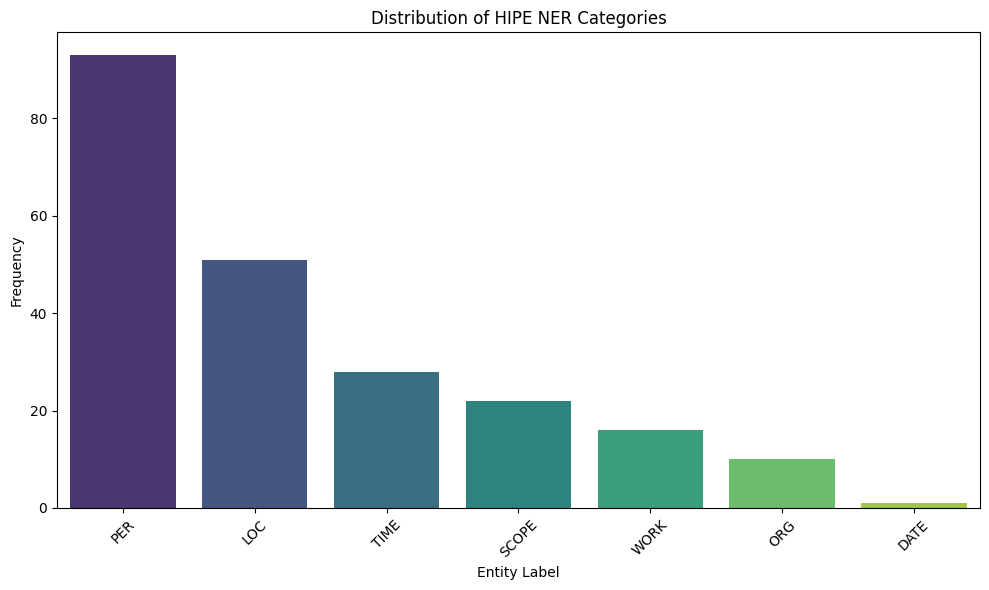

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each label
label_counts = df['label'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', hue=label_counts.index, legend=False)
plt.title('Distribution of HIPE NER Categories')
plt.xlabel('Entity Label')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()